### Table of Contents

1.  Data Loading
2.  Data Cleaning and Preprocessing
3.  Exploratory Data Analysis
4.  Predictive Modeling
5.  Conclusions and Future Work

### Import necessary libraries and suppress warnings

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# Seaborn and matplotlib for visualization
import seaborn as sns
import matplotlib
matplotlib.use('Agg')  # Use Agg backend for matplotlib
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # In case only plt is imported

# Enable inline plotting in Jupyter Notebook
%matplotlib inline

# Scikit-learn for predictive modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.inspection import permutation_importance

sns.set(style='whitegrid')
print('Libraries imported and settings configured.')

Libraries imported and settings configured.


#### **Data Loading**
In this section, we load the drug discovery virtual screening dataset. The dataset contains both protein and compound features along with a binary indicator of activity. We read the data from a CSV file located in the local directory.

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shahriarkabir/drug-discovery-virtual-screening-dataset")

print("Path to dataset files:", path)

100%|██████████| 199k/199k [00:00<00:00, 515kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/shahriarkabir/drug-discovery-virtual-screening-dataset/versions/1


In [3]:
from google.colab import files

uploaded = files.upload()

Saving drug_discovery_virtual_screening.csv to drug_discovery_virtual_screening.csv


In [4]:
df = pd.read_csv('drug_discovery_virtual_screening.csv')

df.head()

,compound_id,protein_id,molecular_weight,logp,h_bond_donors,h_bond_acceptors,rotatable_bonds,polar_surface_area,compound_clogp,protein_length,protein_pi,hydrophobicity,binding_site_size,mw_ratio,logp_pi_interaction,binding_affinity,active
0,CID_00000,PID_361,499.671415,2.487233,1,7,4,113.350817,4.050696,678,6.019657,0.812534,12.512165,0.736978,14.972288,5.996665,0
1,CID_00001,PID_165,436.173570,3.283222,3,4,4,71.981132,3.704408,876,6.447408,0.651417,11.538420,0.497915,21.168271,6.445742,0
2,CID_00002,PID_168,514.768854,NaN,2,11,11,83.936307,1.869610,658,3.925837,0.633467,13.155702,0.782323,9.074061,5.689583,0
3,CID_00003,PID_226,602.302986,3.038058,0,5,5,79.868125,2.451909,312,7.597056,0.513038,12.071822,1.930458,23.080293,6.043438,0
4,CID_00004,PID_224,426.584663,0.659578,2,4,5,88.198676,1.771936,1418,4.249454,0.613571,15.850448,0.300835,2.802846,4.845055,0


#### **Data Cleaning and Preprocessing**

We examine the dataset for issues such as missing values, inappropriate data types and outliers. In our particular dataset, most column types are clearly defined. However, it is always good practice to inspect and convert if needed.

In [5]:
# Basic data info and missing values
print('Data Info:')
df.info()

print('\nMissing values per column:')
print(df.isnull().sum())

# Converting columns if necessary (for example, compound_id and protein_id should be strings)
df['compound_id'] = df['compound_id'].astype(str)
df['protein_id'] = df['protein_id'].astype(str)

# Ensure that the target variable 'active' is integer (if not already)
df['active'] = df['active'].astype(int)

# If any date columns were present, this is where we would parse them. Currently, no date column exists.

# Note: Always check for errors when converting types, as this might be a common issue for others using similar datasets.

print('\nData types after conversion:')
print(df.dtypes)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   compound_id          2000 non-null   object 
 1   protein_id           2000 non-null   object 
 2   molecular_weight     2000 non-null   float64
 3   logp                 1940 non-null   float64
 4   h_bond_donors        2000 non-null   int64  
 5   h_bond_acceptors     2000 non-null   int64  
 6   rotatable_bonds      2000 non-null   int64  
 7   polar_surface_area   1940 non-null   float64
 8   compound_clogp       2000 non-null   float64
 9   protein_length       2000 non-null   int64  
 10  protein_pi           2000 non-null   float64
 11  hydrophobicity       1940 non-null   float64
 12  binding_site_size    2000 non-null   float64
 13  mw_ratio             2000 non-null   float64
 14  logp_pi_interaction  2000 non-null   float64
 15  binding_affinity     2000 n

#### **Exploratory Data Analysis**
Let's explore the dataset to find interesting patterns. We will look at basic distributions, correlation heatmaps among the numeric features, and various plots to ascertain the differences between active and inactive compounds.

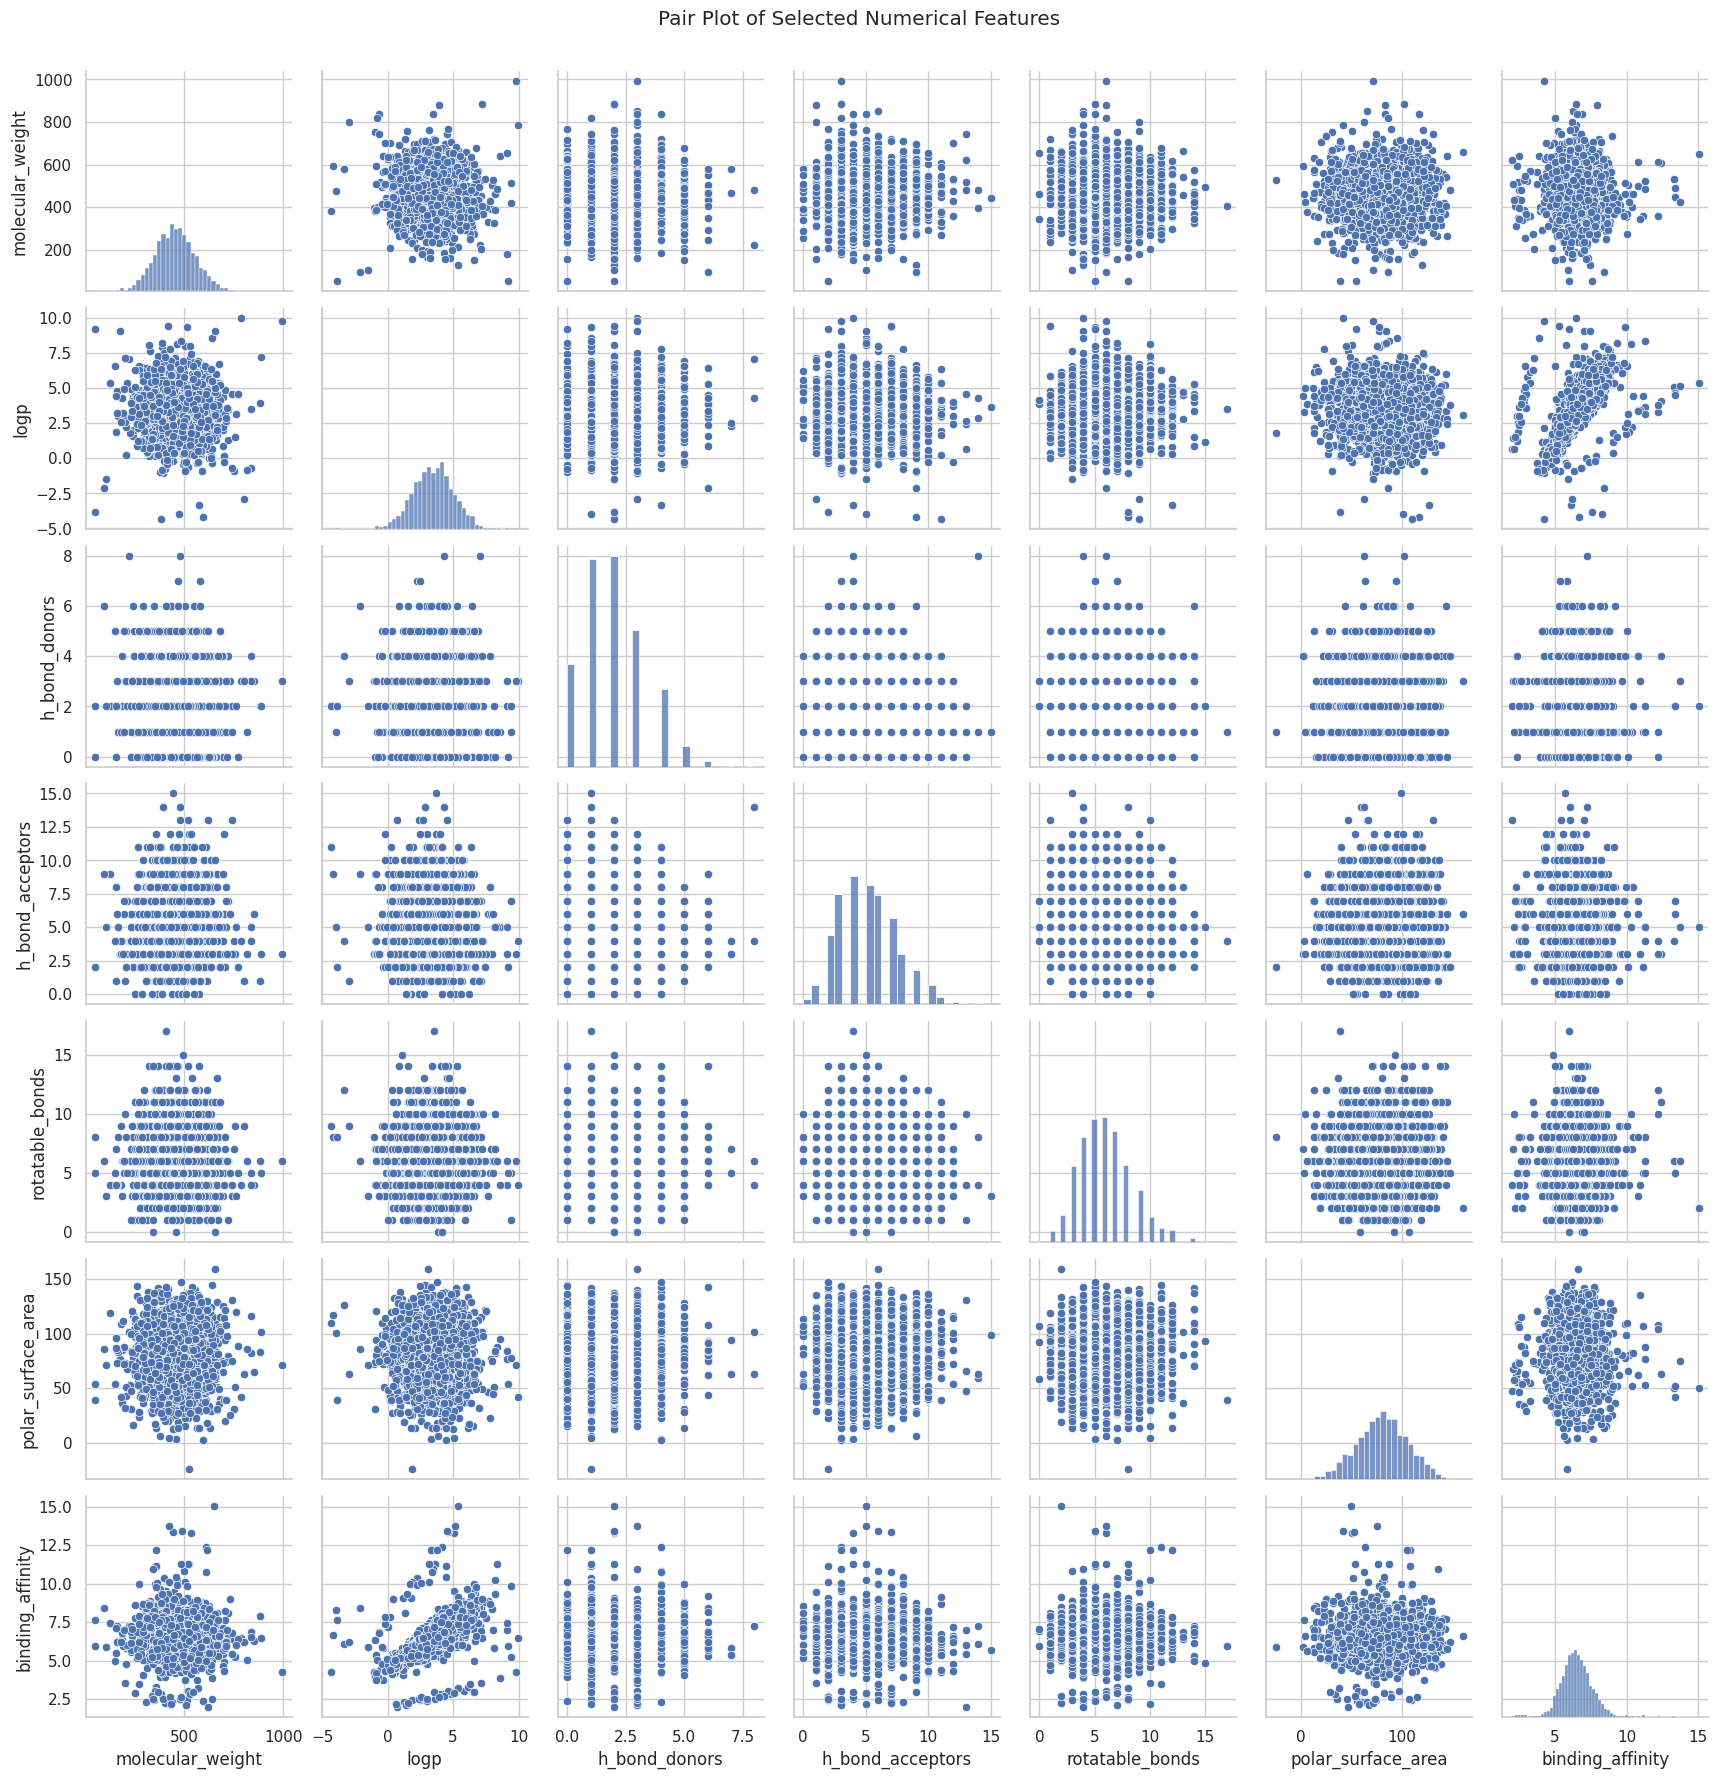

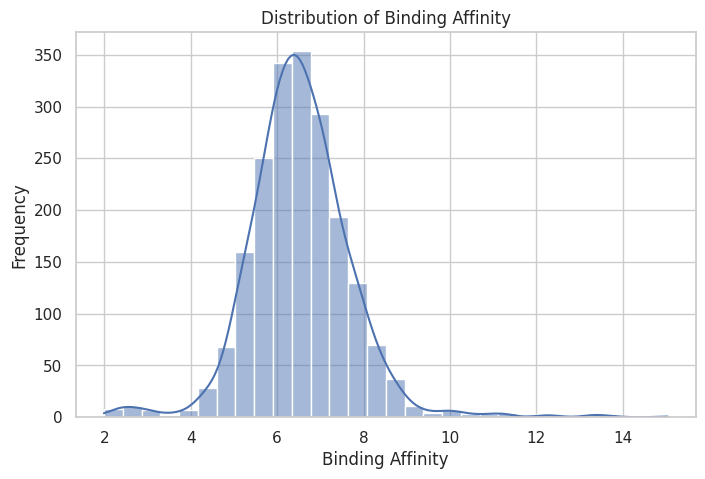

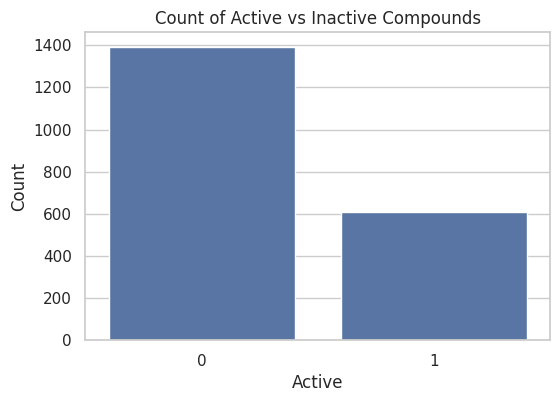

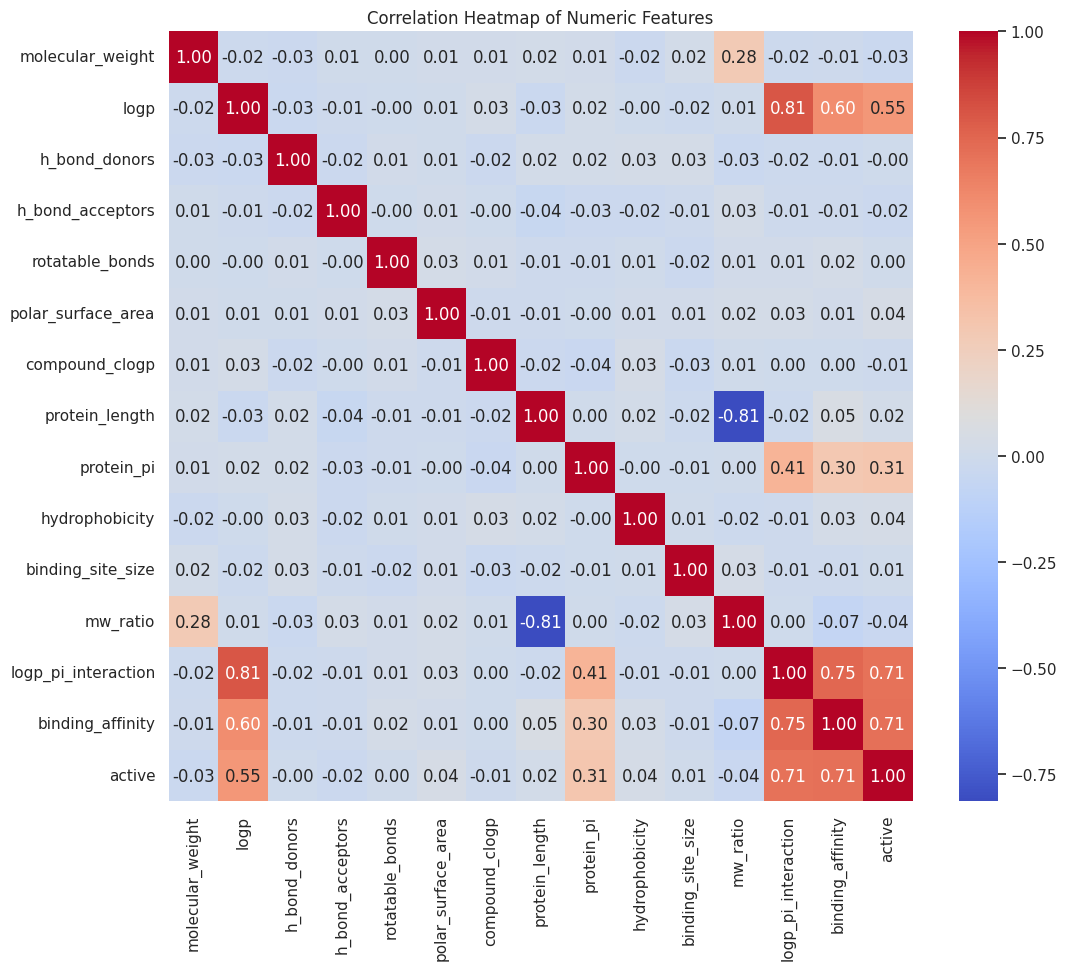

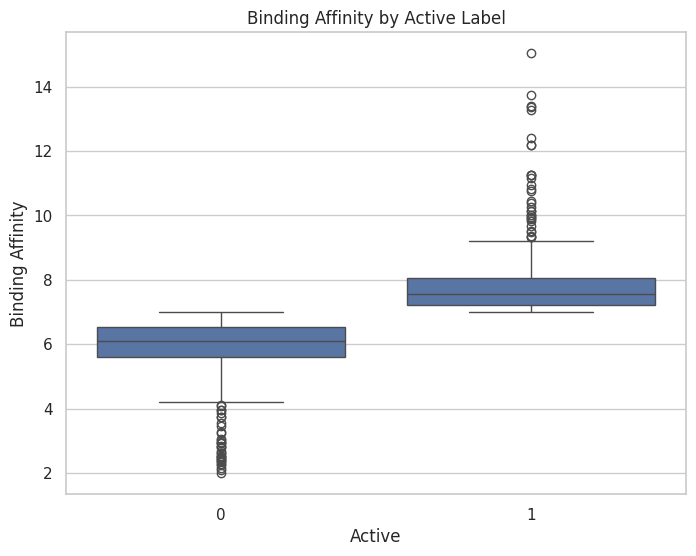

In [6]:
# Create a pair plot of a subset of numerical features to visualize potential trends
numerical_cols = ['molecular_weight', 'logp', 'h_bond_donors', 'h_bond_acceptors', 'rotatable_bonds', 'polar_surface_area', 'binding_affinity']
sns.pairplot(df[numerical_cols], diag_kind='hist')
plt.suptitle('Pair Plot of Selected Numerical Features', y=1.02)
plt.show()

# Histogram for 'binding_affinity' distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['binding_affinity'], kde=True, bins=30)
plt.title('Distribution of Binding Affinity')
plt.xlabel('Binding Affinity')
plt.ylabel('Frequency')
plt.show()

# Count plot (pie chart style) for the target variable 'active'
plt.figure(figsize=(6, 4))
sns.countplot(x='active', data=df)
plt.title('Count of Active vs Inactive Compounds')
plt.xlabel('Active')
plt.ylabel('Count')
plt.show()

# Correlation Heatmap for Numerical Features (only if 4 or more numeric columns exist)
numeric_df = df.select_dtypes(include=[np.number])
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(12, 10))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.show()

# Box Plot for comparing binding affinity based on the 'active' label
plt.figure(figsize=(8, 6))
sns.boxplot(x='active', y='binding_affinity', data=df)
plt.title('Binding Affinity by Active Label')
plt.xlabel('Active')
plt.ylabel('Binding Affinity')
plt.show()

####Predictive Modeling

We build a predictive model to estimate the likelihood of a compound being active based on its features. Here, a logistic regression model is used. Along the way, we calculate performance metrics including the accuracy score and demonstrate the confusion matrix and ROC curve.

Note: In case you encounter any errors during model training, double-check that the feature columns are numeric and no missing values are present.

Prediction Accuracy: 0.9025


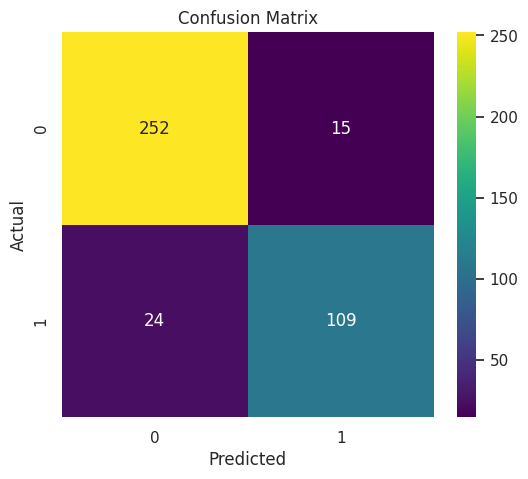

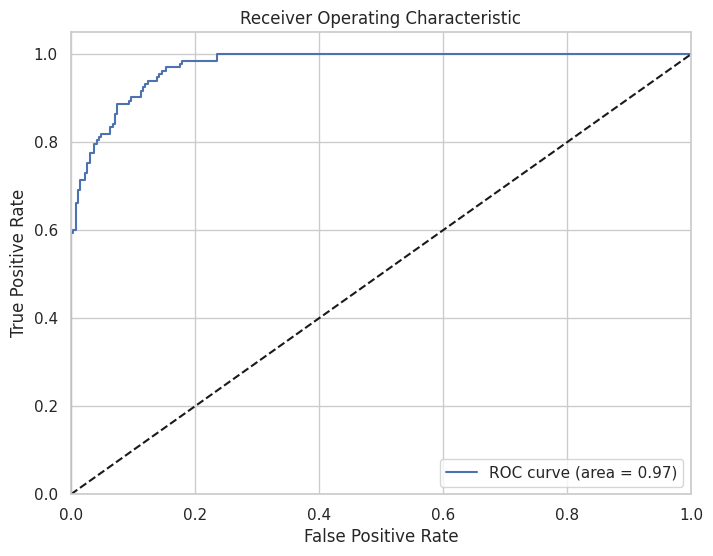

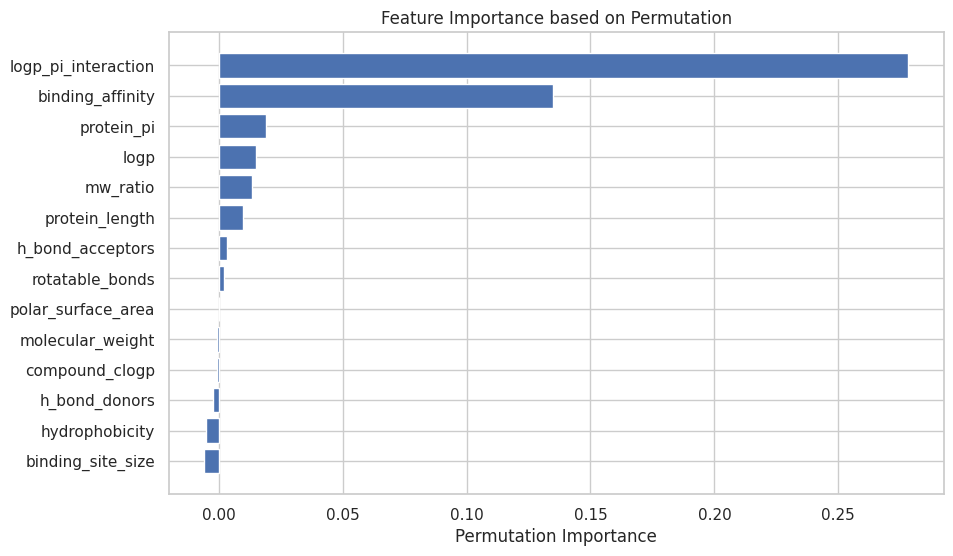

In [7]:
# Prepare the data for modeling
# Let's define the feature set by dropping the identifier columns and the target column
X = df.drop(columns=['compound_id', 'protein_id', 'active'])
y = df['active']

# For simplicity, fill or drop any missing values if present
X = X.fillna(X.mean())

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make predictions and compute accuracy
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print('Prediction Accuracy:', round(accuracy, 4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
y_probs = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

# Permutation Importance
result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, scoring='accuracy')
plt.figure(figsize=(10, 6))
sorted_idx = result.importances_mean.argsort()
plt.barh(np.array(X.columns)[sorted_idx], result.importances_mean[sorted_idx])
plt.xlabel('Permutation Importance')
plt.title('Feature Importance based on Permutation')
plt.show()

#### Conclusions and Future Work
In this notebook, we loaded and preprocessed the drug discovery dataset, performed extensive exploratory data analysis using various visualizations and built a predictive model using logistic regression. Our approach gives a robust starting point in understanding the relationships between molecular features and compound activity.

Future analysis could include:

* Experimenting with more advanced models such as random forests or gradient boosting to possibly improve prediction accuracy.

* Feature engineering and dimensionality reduction techniques, such as PCA or LDA, to capture potential interactions between features.

* Investigating the impact of outliers and using robust statistical methods for better preprocessing.

If you found this notebook insightful, please consider upvoting it.

In [8]:
# Additional concluding print statement
print('Analysis complete. Ideas for future work include exploring more advanced models and feature engineering approaches.')

Analysis complete. Ideas for future work include exploring more advanced models and feature engineering approaches.
